In [92]:
import numpy as np
import matplotlib.pyplot as plt
#write a code to 

In [93]:
import os
import numpy as np

dir = ['/home/apa2237/generative_model_work/adalead/tf_ARX_L343Q_R1_8mers/generative_results',\
       '/home/apa2237/generative_model_work/dyna_ppo/FLEXS/examples/results_tf_ARX_L343Q_R1_8mers',
       '/home/apa2237/generative_model_work/gflownet/BioSeq-GFN-AL/result_tf_arx_l343q',
       ]
# Find all .npy files in the directories that contain dicts
# ignore the files that start with 'sequences_'
# do not plot ourGREEDY results
npy_files = []
method_names = []
for d in dir:
    for file in os.listdir(d):
        if file.endswith('.npy') and not file.startswith(('sequences_', 'cbas', 'dbas', 'bo','dynappo')) and 'ourGREEDY' not in file:
            npy_files.append(os.path.join(d, file))
            method_names.append(os.path.basename(file).split('_')[0])

# reshuffle to make "Ours" last if present
if 'Ours' in method_names:
    idx = method_names.index('Ours')
    npy_files.append(npy_files.pop(idx))
    method_names.append(method_names.pop(idx))
print(npy_files)
print(method_names)

# in the code below, replace f'File {i+1}' with method_names[i]

# Load all dicts from the found .npy files
dicts = []
for file in npy_files:
    arr = np.load(file, allow_pickle=True)
    if isinstance(arr.item(), dict):
        dicts.append(arr.item())

common_keys = set.intersection(*(set(d.keys()) for d in dicts))

# Dictionary to store vals for each method and key
method_vals_storage = {key: {} for key in common_keys}
key_to_minmax = {}
for key in common_keys:
    max_values = []  # Store max value for each method
    
    for i, dct in enumerate(dicts):
        vals = np.array(dct[key])
        
        if len(vals.shape) == 3:
            vals = vals[:, 0:10, 2]
            vals = np.mean(vals, axis=0)
        else:
            vals = np.mean(vals, axis=0)
        
        # Store vals for this method
        method_vals_storage[key][method_names[i]] = vals
        
        # Get max value for this method
        max_val = np.max(vals)
        max_values.append(max_val)
    
    # Find minimum of the max values
    min_max_value = np.min(max_values)
    min_max_method_idx = np.argmin(max_values)
    min_max_method = method_names[min_max_method_idx]
    key_to_minmax[key] = min_max_value ## this is what we need 
    
print(key_to_minmax)

['/home/apa2237/generative_model_work/adalead/tf_ARX_L343Q_R1_8mers/generative_results/adalead.npy', '/home/apa2237/generative_model_work/adalead/tf_ARX_L343Q_R1_8mers/generative_results/cmaes.npy', '/home/apa2237/generative_model_work/adalead/tf_ARX_L343Q_R1_8mers/generative_results/our_1.npy', '/home/apa2237/generative_model_work/adalead/tf_ARX_L343Q_R1_8mers/generative_results/ourEXPLOIT_1.npy', '/home/apa2237/generative_model_work/gflownet/BioSeq-GFN-AL/result_tf_arx_l343q/gflownet_tf_arx_l343q.npy']
['adalead.npy', 'cmaes.npy', 'our', 'ourEXPLOIT', 'gflownet']
{50: 0.5553775963038207, 100: 0.5298503085523844, 20: 0.571646633259952}


## Preparing the data for metric calculation

In [94]:

top_per = 30

data_path = "/home/apa2237/generative_model_work/datasets/tf_ARX_REF_R1/"

seq_start = np.load(f'{data_path}/seq_test.npy', allow_pickle=True).reshape((-1,1))
y_start = np.load(f'{data_path}/y_test.npy', allow_pickle=True).reshape((-1,1))

print('Before filtering',len(seq_start), len(y_start))
print('Mean before', np.mean(y_start))
print('Min before', np.min(y_start))
print('Max before', np.max(y_start))

cap = max(y_start)
floor = min(y_start)
cutoff = 0.2
print('Cutoff', cutoff)
below_idx = (y_start<cutoff)
# print('Below_idx', np.sum(below_idx*1))
print(below_idx.shape,seq_start.shape)

seq_start = seq_start[below_idx]
y_start = y_start[below_idx]

print('Filtering==================')
print('After filtering',len(seq_start), len(y_start))
print('Mean after', np.mean(y_start))
print('Max after', np.max(y_start))

# print(seq_start)


Before filtering 8356 8356
Mean before 0.4462841864646173
Min before 0.0
Max before 0.997026473644679
Cutoff 0.2
(8356, 1) (8356, 1)
Filtering==================
After filtering 353 353
Mean after 0.16152546562691034
Max after 0.1999567861221718


In [95]:
from polyleven import levenshtein

def edit_dist(seq1, seq2):
    return levenshtein(seq1, seq2) / 1

import itertools

def mean_pairwise_distances(args, seqs):
    dists = []
    for pair in itertools.combinations(seqs, 2):
        dists.append(edit_dist(*pair))
    return np.mean(dists)

def novelty(list_1, list_2):
    dists = []
    for s1, s2 in itertools.product(list_1, list_2):  # cross pairs only
        # print(s1,s2)
        dists.append(edit_dist(s1, s2))
    return np.mean(dists) if dists else 0.0


In [96]:
def auc_cal(prop):
    for k in prop.keys():  # show up to 3 keys
        if k not in [20, 50, 100]:
            continue
        # Get data
        if len(prop[k].shape) == 2:
            temp = prop[k]
        else:
            temp = prop[k][..., 2]
        area = []
        for j in range(temp.shape[0]):
            y = temp[j,:]
            # shifting y so that min is zero
            y = y - np.min(y)
            x = np.arange(len(y))
            auc = np.trapz(y, x)
            area.append(auc)
        print(f"Samples:{k}, AUC:{np.mean(area):.2f} ± {np.std(area):.2f}")
    # return area

In [97]:
def find_nearest(arr, target):
    L,R = 0, len(arr)-1
    while L<R:
        mid = (L+R)//2
        if arr[mid]<target:
            L = mid+1
        else:
            R = mid
        
    return R

In [98]:
def cal_d_n(sequences,prop_ada):
    div_res = []
    for k1 in sequences.keys():
        if k1 not in [20, 50, 100]:
            continue
        sum_dist = []
        novel_dist = []
        for k2 in sequences[k1].keys():
            if len(prop_ada[k1][k2].shape)==2:
                idx = find_nearest(prop_ada[k1][k2][1:,2], key_to_minmax[k1])
            else:
                idx = find_nearest(prop_ada[k1][k2][1:], key_to_minmax[k1])
            

            # # if sequences[k1][k2][idx]>=key_to_minmax[k1]:
            # if len(prop_ada[k1][k2].shape)==2:
            #     if 0.8*key_to_minmax[k1] <= prop_ada[k1][k2][idx,2] <= 1.2*key_to_minmax[k1]:
            #         sim = mean_pairwise_distances(None, sequences[k1][k2][idx+1])
            #         sum_dist.append(sim)
            # else:
            #     if 0.8*key_to_minmax[k1] <= prop_ada[k1][k2][idx] <= 1.2*key_to_minmax[k1]:
            sim = mean_pairwise_distances(None, sequences[k1][k2][idx+1])
            sum_dist.append(sim)
            
            nov = novelty(sequences[k1][k2][9],seq_start)
            novel_dist.append(nov)
            
        print(f"Samples:{k1}, Diversity:{np.mean(sum_dist):.2f} ± {np.std(sum_dist):.2f}, \
        Novelty:{np.mean(novel_dist):.2f} ± {np.std(novel_dist):.2f}")
        div_res.append(np.mean(sum_dist))
        
    return div_res


## AUC

In [99]:
data_dir = './generative_results'
path_2 = '/home/apa2237/generative_model_work/dyna_ppo/FLEXS/examples/results_tf_ARX_L343Q_R1_8mers'

prop_bo = np.load(f'{path_2}/bo.npy', allow_pickle=True).tolist()
sequences_bo  = np.load(f'{path_2}/sequences_bo.npy', allow_pickle=True).tolist()
print('--------------BO----------------')
auc_cal(prop_bo)

prop_cmaes = np.load(f'{data_dir}/cmaes.npy', allow_pickle=True).tolist()
sequences_cmaes = np.load(f'{data_dir}/sequences_cmaes.npy', allow_pickle=True).tolist()
print('--------------CMA-ES----------------')
# print(prop_cmaes[20].shape)
auc_cal(prop_cmaes)

prop_ada = np.load(f'{data_dir}/adalead.npy', allow_pickle=True).tolist()
sequences_ada = np.load(f'{data_dir}/sequences_adalead.npy', allow_pickle=True).tolist()
print('--------------AdaLead----------------')
print(prop_ada[20].shape)
auc_cal(prop_ada)

# # Dbas, Cbas, DynaPPO
prop_cbas = np.load(f'{path_2}/cbas.npy', allow_pickle=True).tolist()
sequences_cbas  = np.load(f'{path_2}/sequences_cbas.npy', allow_pickle=True).tolist()
print('--------------Cbas----------------')
auc_cal(prop_cbas)

## Dbas, Cbas, DynaPPO
prop_dbas = np.load(f'{path_2}/dbas.npy', allow_pickle=True).tolist()
sequences_dbas = np.load(f'{path_2}/sequences_dbas.npy', allow_pickle=True).tolist()
print('--------------Dbas----------------')
# print(prop_dbas[20].shape)
auc_cal(prop_dbas)

## GFlowNet
path_gfn = '/home/apa2237/generative_model_work/gflownet/BioSeq-GFN-AL/result_tf_arx_l343q'
prop_gfn = np.load(f'{path_gfn}/gflownet_tf_arx_l343q.npy', allow_pickle=True).tolist()
sequences_gfn = np.load(f'{path_gfn}/sequences_gflownet_tf_arx_l343q.npy', allow_pickle=True).tolist()
print('--------------GFlowNet----------------')
auc_cal(prop_gfn)


prop_dyna = np.load(f'{path_2}/dynappo.npy', allow_pickle=True).tolist()
sequences_dyna = np.load(f'{path_2}/sequences_dynappo.npy', allow_pickle=True).tolist()
print('--------------Dynappo----------------')
# print(prop_dyna[20].shape)
auc_cal(prop_dyna)

prop_mode = np.load(f'{data_dir}/our_1.npy', allow_pickle=True).tolist()
sequences_mode = np.load(f'{data_dir}/sequences_our_1.npy', allow_pickle=True).tolist()
print('--------------IDEAS----------------')
auc_cal(prop_mode)


prop_mode_expl = np.load(f'{data_dir}/ourEXPLOIT_1.npy', allow_pickle=True).tolist()
sequences_mode_expl = np.load(f'{data_dir}/sequences_ourEXPLOIT_1.npy', allow_pickle=True).tolist()
print('--------------IDEAS-X----------------')
auc_cal(prop_mode_expl)

--------------BO----------------
Samples:20, AUC:2.93 ± 0.19
Samples:50, AUC:2.92 ± 0.13
Samples:100, AUC:2.87 ± 0.02
--------------CMA-ES----------------
Samples:20, AUC:4.09 ± 0.44
Samples:50, AUC:4.12 ± 0.27
Samples:100, AUC:4.12 ± 0.30
--------------AdaLead----------------
(10, 11, 3)
Samples:20, AUC:4.58 ± 0.27
Samples:50, AUC:4.72 ± 0.28
Samples:100, AUC:4.83 ± 0.22
--------------Cbas----------------
Samples:20, AUC:3.24 ± 0.22
Samples:50, AUC:3.03 ± 0.02
Samples:100, AUC:3.11 ± 0.11
--------------Dbas----------------
Samples:20, AUC:3.09 ± 0.11
Samples:50, AUC:3.19 ± 0.14
Samples:100, AUC:3.03 ± 0.09
--------------GFlowNet----------------
Samples:20, AUC:3.75 ± 0.17
Samples:50, AUC:3.57 ± 0.15
Samples:100, AUC:3.43 ± 0.13
--------------Dynappo----------------
Samples:20, AUC:3.34 ± 0.07
Samples:50, AUC:3.30 ± 0.02
Samples:100, AUC:3.36 ± 0.08
--------------IDEAS----------------
Samples:20, AUC:4.72 ± 0.26
Samples:50, AUC:4.72 ± 0.17
Samples:100, AUC:4.84 ± 0.11
--------------IDE

## Diversity and Novelty

In [100]:

print('--------------AdaLead----------------')
cal_d_n(sequences_ada,prop_ada)

print('--------------CMA-ES----------------')
cal_d_n(sequences_cmaes, prop_cmaes)

print('--------------Dynappo----------------')
cal_d_n(sequences_dyna, prop_dyna)

print('--------------GFlowNet----------------')
cal_d_n(sequences_gfn, prop_gfn)

print('--------------IDEAS----------------')
div_idea = cal_d_n(sequences_mode, prop_mode  )

print('--------------IDEAS-X----------------')
div_idea_expl = cal_d_n(sequences_mode_expl, prop_mode_expl)

# find the mean difference between div_idea and div_idea_expl]
diff_div = [100*(i-j)/j for i,j in zip( div_idea, div_idea_expl)]
print(f'Mean diff : {np.mean(diff_div):.2f}')

--------------AdaLead----------------
Samples:20, Diversity:2.07 ± 0.62,         Novelty:5.91 ± 0.17
Samples:50, Diversity:2.94 ± 0.85,         Novelty:5.93 ± 0.12
Samples:100, Diversity:2.79 ± 0.87,         Novelty:5.89 ± 0.12
--------------CMA-ES----------------
Samples:20, Diversity:2.61 ± 0.28,         Novelty:5.80 ± 0.17
Samples:50, Diversity:2.72 ± 0.22,         Novelty:5.79 ± 0.13
Samples:100, Diversity:2.95 ± 0.09,         Novelty:5.77 ± 0.13
--------------Dynappo----------------
Samples:20, Diversity:4.59 ± 0.05,         Novelty:5.68 ± 0.05
Samples:50, Diversity:4.65 ± 0.08,         Novelty:5.75 ± 0.04
Samples:100, Diversity:4.74 ± 0.02,         Novelty:5.62 ± 0.07
--------------GFlowNet----------------
Samples:20, Diversity:4.42 ± 0.36,         Novelty:5.87 ± 0.29
Samples:50, Diversity:4.69 ± 0.23,         Novelty:5.78 ± 0.26
Samples:100, Diversity:4.69 ± 0.25,         Novelty:5.73 ± 0.25
--------------IDEAS----------------
Samples:20, Diversity:2.99 ± 0.53,         Novelty:6

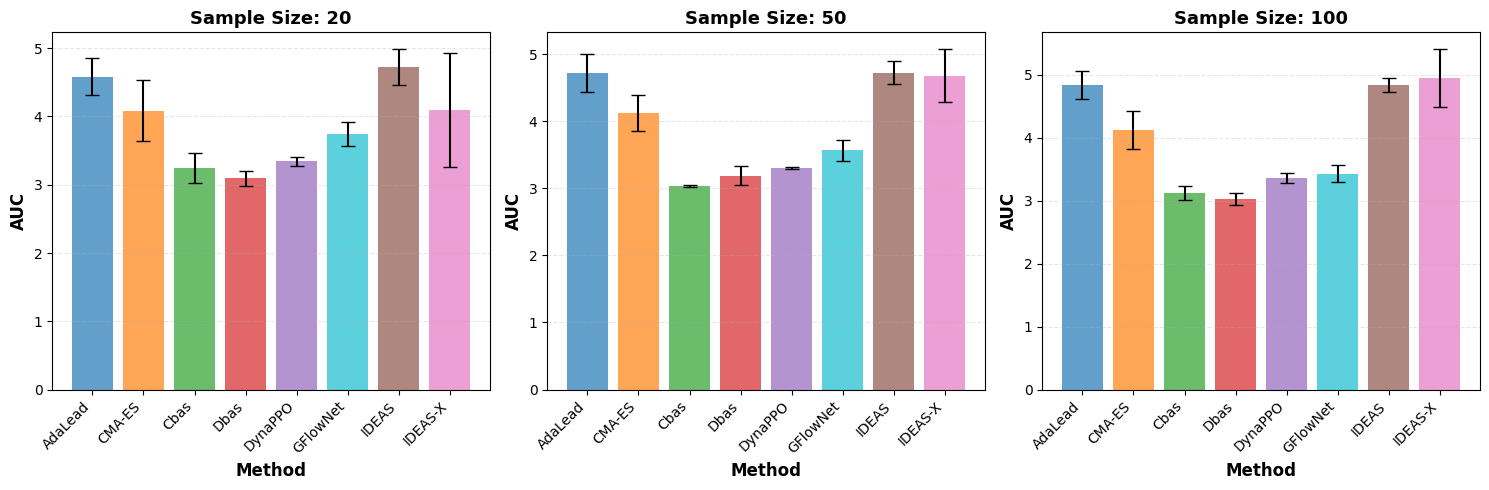

In [101]:
# Collect AUC data for plotting
methods_data = {
    'AdaLead': prop_ada,
    'CMA-ES': prop_cmaes,
    'Cbas': prop_cbas,
    'Dbas': prop_dbas,
    'DynaPPO': prop_dyna,
    'GFlowNet': prop_gfn,
    'IDEAS': prop_mode,
    'IDEAS-X': prop_mode_expl
}

sample_sizes = [20, 50, 100]
auc_results = {method: {k: [] for k in sample_sizes} for method in methods_data.keys()}

# Calculate AUC for each method and sample size
for method_name, prop in methods_data.items():
    for k in sample_sizes:
        if k in prop:
            # Get data
            if len(prop[k].shape) == 2:
                temp = prop[k]
            else:
                temp = prop[k][..., 2]

            area = []
            for j in range(temp.shape[0]):
                y = temp[j,:]
                y = y - np.min(y)  # shift so min is zero
                x = np.arange(len(y))
                auc = np.trapz(y, x)
                area.append(auc)

            auc_results[method_name][k] = area

# Create the plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, k in enumerate(sample_sizes):
    ax = axes[idx]

    # Prepare data for this sample size
    method_names = list(methods_data.keys())
    means = [np.mean(auc_results[m][k]) if auc_results[m][k] else 0 for m in method_names]
    stds = [np.std(auc_results[m][k]) if auc_results[m][k] else 0 for m in method_names]

    # Create bar plot
    x_pos = np.arange(len(method_names))
    bars = ax.bar(x_pos, means, yerr=stds, alpha=0.7, capsize=5,
                   color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#17becf', '#8c564b', '#e377c2'])

    # Customize plot
    ax.set_xlabel('Method', fontsize=12, fontweight='bold')
    ax.set_ylabel('AUC', fontsize=12, fontweight='bold')
    ax.set_title(f'Sample Size: {k}', fontsize=13, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(method_names, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Add value labels on bars
    # for i, (m, s) in enumerate(zip(means, stds)):
    #     ax.text(i, m + s + 0.5, f'{m:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Diversity and Novelty calculation complete!


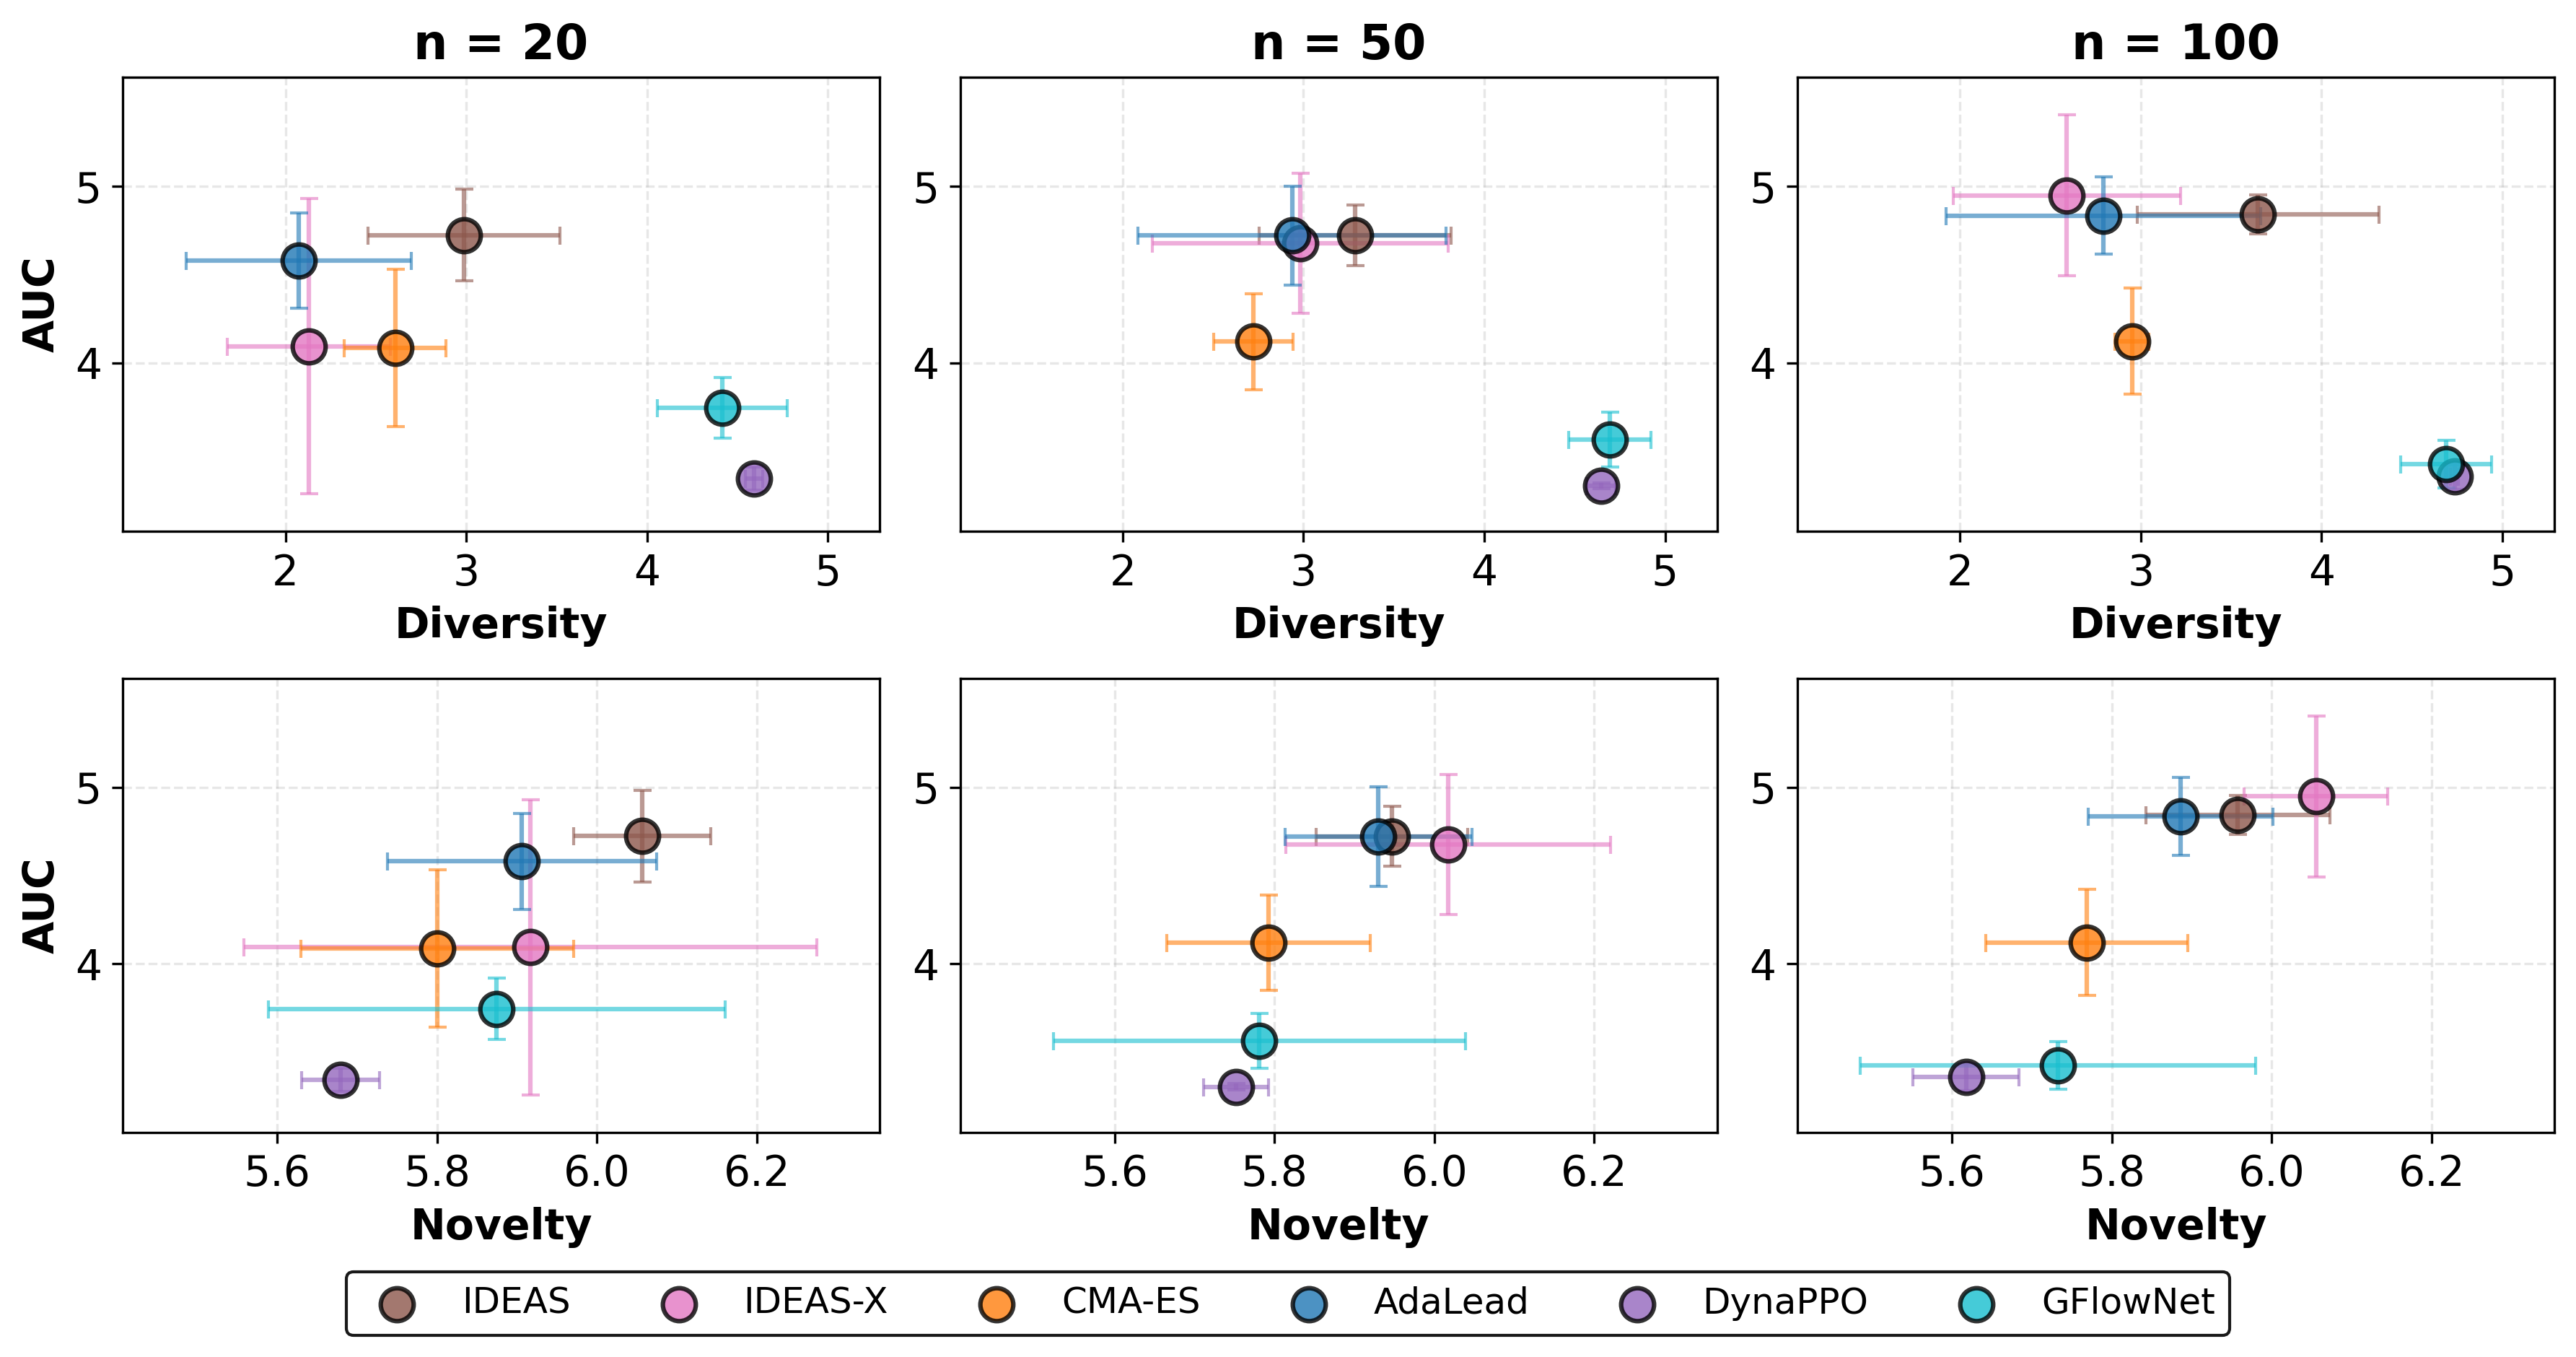

In [102]:
# ========== AUC vs Diversity & Novelty Scatter Plots (2x3 Subfigure) ==========

# Step 1: Calculate Diversity and Novelty Data
diversity_methods_data = {
    'AdaLead': (sequences_ada, prop_ada),
    'CMA-ES': (sequences_cmaes, prop_cmaes),
    'Cbas': (sequences_cbas, prop_cbas),
    'Dbas': (sequences_dbas, prop_dbas),
    'DynaPPO': (sequences_dyna, prop_dyna),
    'GFlowNet': (sequences_gfn, prop_gfn),
    'IDEAS': (sequences_mode, prop_mode),
    'IDEAS-X': (sequences_mode_expl, prop_mode_expl)
}

diversity_results = {method: {k: [] for k in [20, 50, 100]} 
                    for method in diversity_methods_data.keys()}
novelty_results = {method: {k: [] for k in [20, 50, 100]} 
                  for method in diversity_methods_data.keys()}

# Calculate diversity and novelty for each method
for method_name, (sequences, prop) in diversity_methods_data.items():
    for k in [20, 50, 100]:
        if k in sequences:
            sum_dist = []
            novel_dist = []
            for k2 in sequences[k].keys():
                if len(prop[k][k2].shape)==2:
                    idx = find_nearest(prop[k][k2][1:,2], key_to_minmax[k])
                else:
                    idx = find_nearest(prop[k][k2][1:], key_to_minmax[k])
                
                # Diversity calculation
                sim = mean_pairwise_distances(None, sequences[k][k2][idx+1])
                sum_dist.append(sim)
                
                # Novelty calculation
                nov = novelty(sequences[k][k2][9], seq_start)
                novel_dist.append(nov)
            
            diversity_results[method_name][k] = sum_dist
            novelty_results[method_name][k] = novel_dist

print("Diversity and Novelty calculation complete!")

# Step 2: Parametric Configuration
PLOT_CONFIG = {
    'default_methods': ['IDEAS', 'IDEAS-X', 'CMA-ES', 'AdaLead', 'DynaPPO', 'GFlowNet'],
    'all_methods': ['IDEAS', 'IDEAS-X', 'CMA-ES', 'AdaLead', 
                    'Cbas', 'Dbas', 'DynaPPO', 'GFlowNet'],
    'sample_sizes': [20, 50, 100],
    'marker_size': 120,
    'colors': {
        'IDEAS': '#8c564b',          # brown - highlight as proposed method
        'IDEAS-X': '#e377c2',        # pink - variant
        'CMA-ES': '#ff7f0e',         # orange - baseline
        'AdaLead': '#1f77b4',        # blue - competitor
        'Cbas': '#2ca02c',           # green
        'Dbas': '#d62728',           # red
        'DynaPPO': '#9467bd',        # purple
        'GFlowNet': '#17becf'        # cyan
    },
    'show_error_bars': True
}

methods_to_plot = PLOT_CONFIG['default_methods']
sample_sizes = PLOT_CONFIG['sample_sizes']

# Step 3: Calculate global axis ranges for both rows
# Row 1: AUC vs Diversity
all_divs, all_aucs_div = [], []
# Row 2: AUC vs Novelty  
all_novs, all_aucs_nov = [], []

for method in methods_to_plot:
    for size in sample_sizes:
        div_mean = np.mean(diversity_results[method][size])
        div_std = np.std(diversity_results[method][size])
        nov_mean = np.mean(novelty_results[method][size])
        nov_std = np.std(novelty_results[method][size])
        auc_mean = np.mean(auc_results[method][size])
        auc_std = np.std(auc_results[method][size])
        
        all_divs.extend([div_mean - div_std, div_mean + div_std])
        all_novs.extend([nov_mean - nov_std, nov_mean + nov_std])
        all_aucs_div.extend([auc_mean - auc_std, auc_mean + auc_std])
        all_aucs_nov.extend([auc_mean - auc_std, auc_mean + auc_std])

# Set consistent ranges with padding
div_min, div_max = min(all_divs), max(all_divs)
nov_min, nov_max = min(all_novs), max(all_novs)
auc_min, auc_max = min(all_aucs_div + all_aucs_nov), max(all_aucs_div + all_aucs_nov)

div_padding = (div_max - div_min) * 0.1
nov_padding = (nov_max - nov_min) * 0.1
auc_padding = (auc_max - auc_min) * 0.1

# Step 4: Create 2x3 subplots
fig, axes = plt.subplots(2, 3, figsize=(12, 6), dpi=300)

# Collect handles and labels for shared legend
handles, labels = None, None

# Row 1: AUC vs Diversity
for idx, size in enumerate(sample_sizes):
    ax = axes[0, idx]
    
    for method in methods_to_plot:
        auc_mean = np.mean(auc_results[method][size])
        auc_std = np.std(auc_results[method][size])
        div_mean = np.mean(diversity_results[method][size])
        div_std = np.std(diversity_results[method][size])
        
        ax.scatter(div_mean, auc_mean,
                  s=PLOT_CONFIG['marker_size'],
                  color=PLOT_CONFIG['colors'][method],
                  edgecolors='black',
                  linewidth=1.5,
                  alpha=0.8,
                  label=f"{method}",
                  zorder=3)
        
        if PLOT_CONFIG['show_error_bars']:
            ax.errorbar(div_mean, auc_mean,
                       xerr=div_std, yerr=auc_std,
                       fmt='none', 
                       ecolor=PLOT_CONFIG['colors'][method],
                       alpha=0.6,
                       capsize=3,
                       zorder=2)
    
    # Capture handles and labels from first subplot
    if idx == 0:
        handles, labels = ax.get_legend_handles_labels()
    
    ax.set_xlim(div_min - div_padding, div_max + div_padding)
    ax.set_ylim(auc_min - auc_padding, auc_max + auc_padding)
    ax.set_title(f'n = {size}', fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(axis='both', labelsize=14)
    ax.set_xlabel('Diversity', fontsize=14, fontweight='bold')
    if idx == 0:
        ax.set_ylabel('AUC', fontsize=14, fontweight='bold')

# Row 2: AUC vs Novelty
for idx, size in enumerate(sample_sizes):
    ax = axes[1, idx]
    
    for method in methods_to_plot:
        auc_mean = np.mean(auc_results[method][size])
        auc_std = np.std(auc_results[method][size])
        nov_mean = np.mean(novelty_results[method][size])
        nov_std = np.std(novelty_results[method][size])
        
        ax.scatter(nov_mean, auc_mean,
                  s=PLOT_CONFIG['marker_size'],
                  color=PLOT_CONFIG['colors'][method],
                  edgecolors='black',
                  linewidth=1.5,
                  alpha=0.8,
                  label=f"{method}",
                  zorder=3)
        
        if PLOT_CONFIG['show_error_bars']:
            ax.errorbar(nov_mean, auc_mean,
                       xerr=nov_std, yerr=auc_std,
                       fmt='none', 
                       ecolor=PLOT_CONFIG['colors'][method],
                       alpha=0.6,
                       capsize=3,
                       zorder=2)
    
    ax.set_xlim(nov_min - nov_padding, nov_max + nov_padding)
    ax.set_ylim(auc_min - auc_padding, auc_max + auc_padding)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(axis='both', labelsize=14)
    ax.set_xlabel('Novelty', fontsize=14, fontweight='bold')
    if idx == 0:
        ax.set_ylabel('AUC', fontsize=14, fontweight='bold')

# Add single legend at bottom center
fig.legend(handles, labels, 
          loc='lower center', 
          bbox_to_anchor=(0.5, -0.05),
          ncol=len(methods_to_plot),
          framealpha=0.9, 
          fontsize=12,
          edgecolor='black')

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)  # Make room for legend
plt.show()